## Photodiode Transimpedance Amplifier — Design & Noise Analysis
#### N. Moteki
#### ref. Graeme 1996, *Photodiode Amplifiers*

### Application: balanced (differential) detection
Two identical photodiodes are connected to two identical TIA channels.
The small difference between their output voltages is extracted as the signal.

**Design constraints:**
- Low and stable I_b is essential (JFET-input): inter-channel offset = R_f × ΔI_b
- Low temperature drift of I_b: bipolar opamps produce unacceptable offset drift
- Noise performance is secondary to I_b stability

In [1]:
from tia_design import *

# Load component databases from CSV
opamps = load_opamps()
photodiodes = load_photodiodes()

print('Opamps:', list(opamps.keys()))
print('Photodiodes:', list(photodiodes.keys()))

Opamps: ['OPA827', 'OPA810', 'OPA380', 'LT1028', 'OPA470', 'AD8672', 'AD8634', 'LT1678', 'LT1364']
Photodiodes: ['PIN-6D', 'SPOT-9DMI']


### 1. Experimental conditions

In [2]:
# --- Select components ---
opamp = opamps['OPA827']
pd    = photodiodes['PIN-6D']

# --- Operating conditions ---
R_f     = 20e3      # feedback resistance [Ohm]
Vb      = 12        # reverse bias voltage [V]
E_photo = 0.15e-3   # incident optical power [W]
T       = 296       # temperature [K] (23 C)
C_s     = 0         # stray capacitance [F]

# Optional: override C_d if measured value differs from model
C_d_override = None  # e.g. 6e-12 for measured 6 pF

print(f'Opamp: {opamp.name} ({opamp.input_type})')
print(f'Photodiode: {pd.name}')
print(f'R_f = {R_f/1e3:.0f} kOhm')
print(f'C_d (model) = {pd.C_d(Vb)/1e-12:.1f} pF')
if C_d_override is not None:
    print(f'C_d (override) = {C_d_override/1e-12:.1f} pF')
print(f'I_p = {E_photo * pd.r_phi * 1e6:.1f} uA')
print(f'R_f * I_p = {R_f * E_photo * pd.r_phi * 1e3:.2f} mV')

Opamp: OPA827 (JFET)
Photodiode: PIN-6D
R_f = 20 kOhm
C_d (model) = 55.0 pF
I_p = 82.5 uA
R_f * I_p = 1650.00 mV


### 2. Single-opamp design & noise analysis

In [3]:
result = design_tia(opamp, pd, R_f, Vb, E_photo, T=T, C_s=C_s,
                    C_d_override=C_d_override)
print_result(result)

=== TIA Design: OPA827 ===
  C_d  = 55.0 pF,  C_i = 73.0 pF
  C_f  = 7.26 pF  (Butterworth optimum)
  BW   = 1.48 MHz,  NEB = 1.64 MHz
  Noise gain peak = 11.1

  Noise breakdown (output-referred RMS):
    E_noe  (opamp voltage) = 79.7 uV
    E_noR  (Rf thermal)    = 23.2 uV
    E_noi_bias (Ib shot)   = 0.025 uV
    E_noi_dark (Id shot)   = 0.339 uV
    E_noi_nif  (in floor)  = 0.056 uV
    E_no_bg    (total BG)  = 83.0 uV
    E_noi_sig  (sig shot)  = 131.6 uV

  Figures of merit:
    Signal         = 1650.00 mV
    SNR            = 10604  (80.5 dB)
    bg/shot ratio  = 0.63  (shot-noise limited)
    Offset/ch      = 60.0 nV

  Hobbs criteria:
    PASS  i_nif < 0.5*sqrt(4kT/Rf)
    PASS  e_nif < 0.5*Rf*sqrt(4kT/Rf)
    FAIL  e_nif < 0.5*sqrt(4kT/Rf)/(2pi*BW*Ci)
    PASS  f_c > 2*BW^2/f_pf
    FAIL  f_c < 10*BW^2/f_pf


### 3. Compare all opamps

In [4]:
# Compare all opamps in the database
df_all = compare_opamps(opamps, pd, R_f, Vb, E_photo, T=T, C_s=C_s,
                        C_d_override=C_d_override)
df_all

,opamp,input,e_nif [nV/rtHz],I_b [pA],C_in [pF],C_f [pF],BW [MHz],E_noe [uV],E_noR [uV],E_no_bg [uV],E_noi_sig [uV],bg/shot,SNR,offset/ch [uV],Hobbs pass
0,LT1028,bipolar,0.85,25000.0,5.00,3.567636,3.063351,39.882575,33.345040,63.832979,189.553937,0.336754,8249.448916,500.00,2
1,AD8672,bipolar,2.80,5000.0,13.75,10.432518,1.002285,31.004216,19.073419,36.958417,108.425169,0.340866,14404.058897,100.00,4
2,OPA470,bipolar,3.50,15000.0,2.00,12.228011,0.830287,25.749822,17.359884,33.867516,98.684374,0.343190,15814.573131,300.00,3
3,AD8634,bipolar,4.20,45000.0,3.60,9.773919,1.062264,43.903085,19.635825,49.898175,111.622236,0.447027,13494.996224,900.00,3
4,OPA827,JFET,4.00,3.0,18.00,7.259693,1.476624,79.731177,23.150894,83.024955,131.604073,0.630869,10603.803222,0.06,3
5,LT1678,bipolar,5.30,3000.0,4.20,6.854005,1.551865,93.886512,23.733388,97.163709,134.915332,0.720183,9924.117156,60.00,4
6,OPA810,JFET,6.30,2.0,2.50,3.614955,3.018249,278.080610,33.098656,280.043954,188.153335,1.488382,4890.605665,0.04,3
7,LT1364,bipolar,9.00,600000.0,3.00,3.630645,3.005602,398.076377,33.029236,401.432071,187.758713,2.138021,3723.163000,12000.00,1
8,OPA380,CMOS,67.00,3.0,4.10,3.232506,3.388800,3584.311347,35.071620,3584.482985,199.368890,17.979149,459.607064,0.06,2


In [5]:
# Compare JFET-input opamps only (suitable for balanced detection)
jfet_opamps = {k: v for k, v in opamps.items() if v.input_type == 'JFET'}
df_jfet = compare_opamps(jfet_opamps, pd, R_f, Vb, E_photo, T=T, C_s=C_s,
                         C_d_override=C_d_override)
df_jfet

,opamp,input,e_nif [nV/rtHz],I_b [pA],C_in [pF],C_f [pF],BW [MHz],E_noe [uV],E_noR [uV],E_no_bg [uV],E_noi_sig [uV],bg/shot,SNR,offset/ch [uV],Hobbs pass
0,OPA827,JFET,4.0,3.0,18.0,7.259693,1.476624,79.731177,23.150894,83.024955,131.604073,0.630869,10603.803222,0.06,3
1,OPA810,JFET,6.3,2.0,2.5,3.614955,3.018249,278.080610,33.098656,280.043954,188.153335,1.488382,4890.605665,0.04,3


### 4. Parameter sweep (optional)

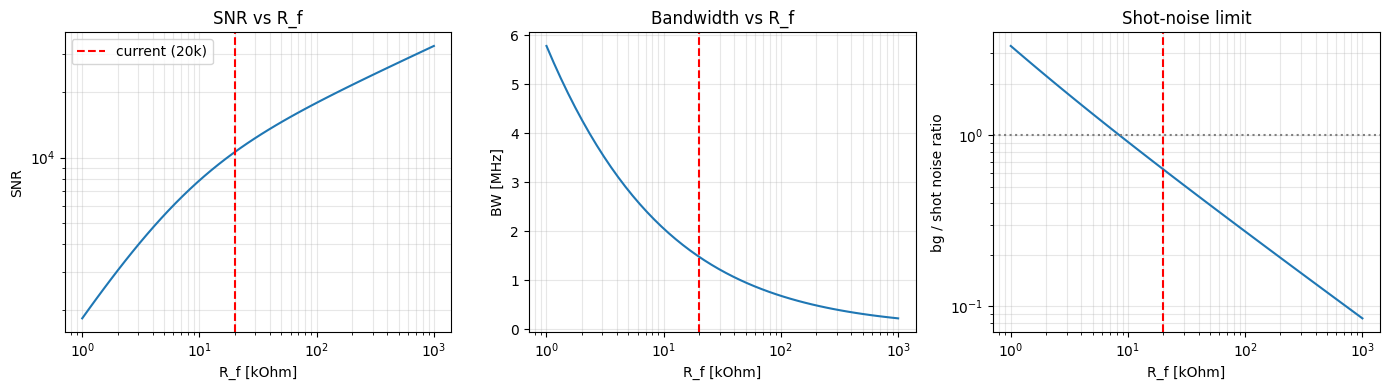

In [7]:
import matplotlib.pyplot as plt

# Sweep R_f to explore bandwidth vs noise trade-off
R_f_values = np.logspace(3, 6, 50)  # 1 kOhm to 1 MOhm
snr_vals = []
bw_vals = []
bg_shot_vals = []

for R in R_f_values:
    r = design_tia(opamp, pd, R, Vb, E_photo, T=T, C_s=C_s,
                   C_d_override=C_d_override)
    snr_vals.append(r.snr)
    bw_vals.append(r.BW_t)
    bg_shot_vals.append(r.bg_to_shot_ratio)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].loglog(R_f_values / 1e3, snr_vals)
axes[0].set_xlabel('R_f [kOhm]')
axes[0].set_ylabel('SNR')
axes[0].set_title('SNR vs R_f')
axes[0].axvline(R_f / 1e3, color='r', ls='--', label=f'current ({R_f/1e3:.0f}k)')
axes[0].legend()
axes[0].grid(True, which='both', alpha=0.3)

axes[1].semilogx(R_f_values / 1e3, np.array(bw_vals) / 1e6)
axes[1].set_xlabel('R_f [kOhm]')
axes[1].set_ylabel('BW [MHz]')
axes[1].set_title('Bandwidth vs R_f')
axes[1].axvline(R_f / 1e3, color='r', ls='--')
axes[1].grid(True, which='both', alpha=0.3)

axes[2].loglog(R_f_values / 1e3, bg_shot_vals)
axes[2].axhline(1, color='gray', ls=':')
axes[2].set_xlabel('R_f [kOhm]')
axes[2].set_ylabel('bg / shot noise ratio')
axes[2].set_title('Shot-noise limit')
axes[2].axvline(R_f / 1e3, color='r', ls='--')
axes[2].grid(True, which='both', alpha=0.3)

fig.tight_layout()
plt.show()